# Import dependencies

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc


# set seed
keras.utils.set_random_seed(42)

# Useful functions

In [10]:
def plot_performance(history):

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))


    train_acc = history.history['accuracy']
    valid_acc = history.history['val_accuracy']
    train_loss = history.history['loss']
    valid_loss = history.history['val_loss']


    epochs = range(1, len(train_acc) + 1)

    # plot loss
    ax[0].plot(epochs, train_loss, 'b-', label='Training Loss')
    ax[0].plot(epochs, valid_loss, 'r--', label='Validation Loss')

    ax[0].set_title('Training & Validation Loss', fontsize=14)
    ax[0].set_xlabel('Epochs', fontsize=12)
    ax[0].set_ylabel('Loss', fontsize=12)
    ax[0].legend(loc='best')
    ax[0].grid(True, linestyle='--', alpha=0.6)

    # plot accuracy
    ax[1].plot(epochs, train_acc, 'b-', label='Training Accuracy')
    ax[1].plot(epochs, valid_acc, 'r--', label='Validation Accuracy')

    ax[1].set_title('Training & Validation Accuracy', fontsize=14)
    ax[1].set_xlabel('Epochs', fontsize=12)
    ax[1].set_ylabel('Accuracy', fontsize=12)
    ax[1].legend(loc='lower right')
    ax[1].grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()
    plt.show()

# Dataset import

In [2]:
# load the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# number of classes
num_class = np.max(y_train) + 1

# check the split dimension
print(f"train dimension {x_train.shape}, {y_train.shape}")
print(f"test dimension {x_test.shape}, {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train dimension (60000, 28, 28), (60000,)
test dimension (10000, 28, 28), (10000,)


## Dataset distribution

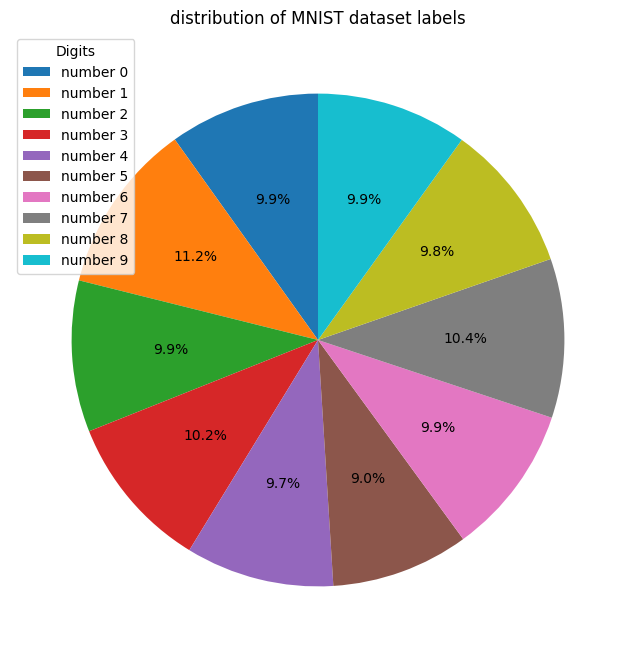

In [3]:
y_train_labels = np.argmax(y_train, axis=1) if y_train.ndim > 1 else y_train

label_counts = np.bincount(y_train_labels)
pie_labels = [str(f"number {i}") for i in range(len(label_counts))]

plt.figure(figsize=(8, 8))
plt.pie(label_counts, autopct='%1.1f%%', startangle=90)
plt.title('distribution of MNIST dataset labels')
plt.legend(pie_labels, title="Digits")
plt.show()

## Example visualization

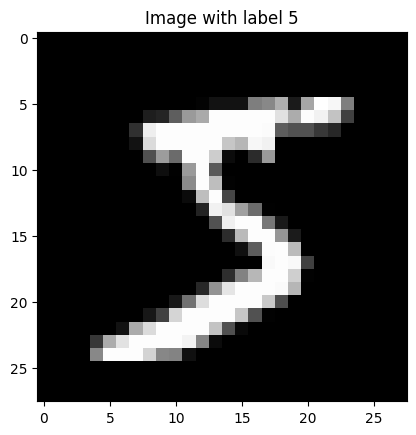

In [ ]:
# show the first element
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.title(f"Image with label {y_train[0]}")
plt.show()


### Data preparation

In [6]:
# scale images into the [0 1] range
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# make images with size (28,28,1).
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(f"train dimension after expanding process {x_train.shape}")
print(f"test dimension after expanding process {x_test.shape}")

train dimension after expanding process (60000, 28, 28, 1)
test dimension after expanding process (10000, 28, 28, 1)


In [7]:
# convert class array into one-hot representation
y_train = keras.utils.to_categorical(y_train, num_class)
y_test = keras.utils.to_categorical(y_test, num_class)

# Baseline model

In [4]:
input_shape = (28,28,1)

given_model = keras.Sequential(
    [
      keras.Input(shape=input_shape),
      layers.Conv2D(32, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Conv2D(64, kernel_size=3, activation="relu"),
      layers.MaxPool2D(pool_size=2),
      layers.Flatten(),
      layers.Dropout(0.5),
      layers.Dense(num_class, activation="softmax")
    ]
)
given_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## Baseline model training

In [8]:
given_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
given_history = given_model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7514 - loss: 0.8027 - val_accuracy: 0.9695 - val_loss: 0.1007
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9617 - loss: 0.1259 - val_accuracy: 0.9799 - val_loss: 0.0678
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9716 - loss: 0.0901 - val_accuracy: 0.9841 - val_loss: 0.0569
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9773 - loss: 0.0750 - val_accuracy: 0.9858 - val_loss: 0.0485
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9804 - loss: 0.0639 - val_accuracy: 0.9866 - val_loss: 0.0470


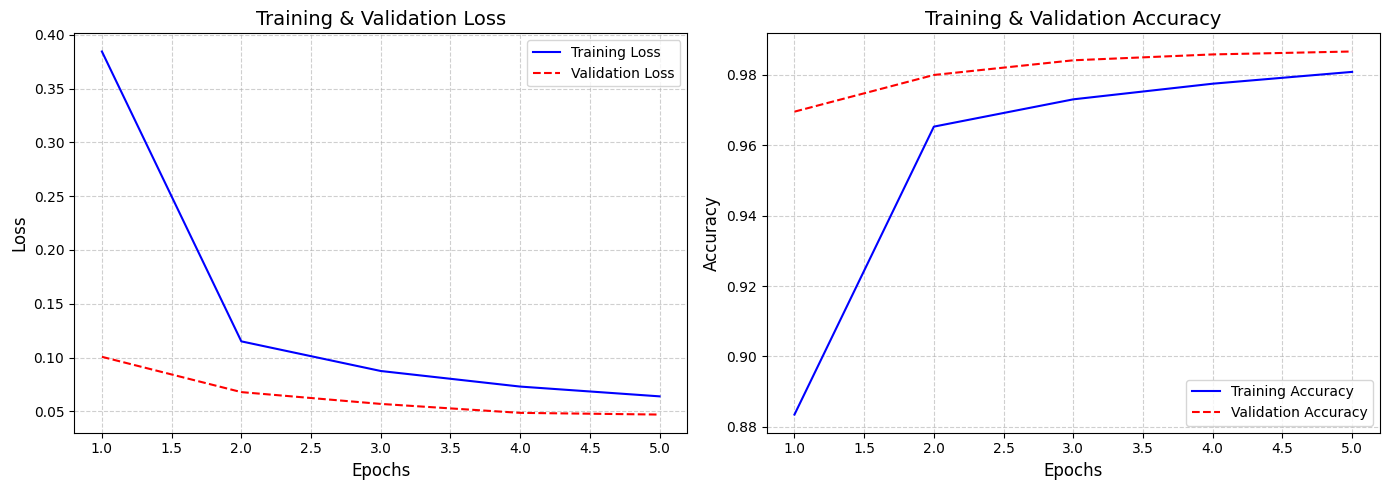

In [11]:
plot_performance(given_history)

## Baseline model evaluation

In [12]:
score = given_model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {score[0]}')
print(f'Test accuracy: {score[1]}')

Test loss: 0.03976844996213913
Test accuracy: 0.987500011920929


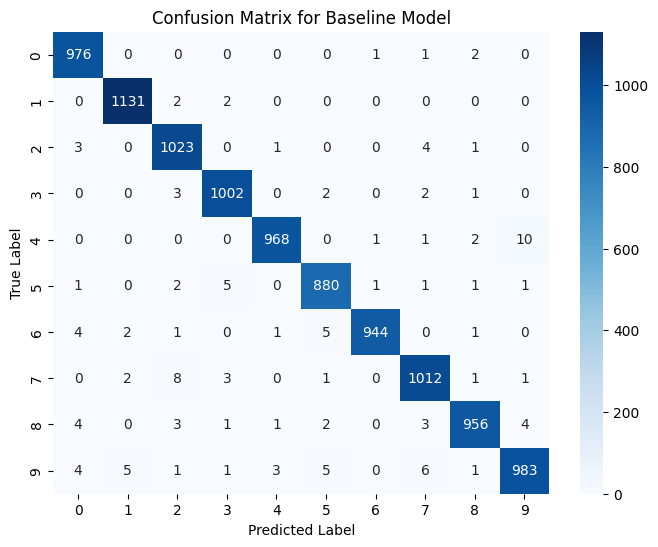

In [13]:
y_pred = np.argmax(given_model.predict(x_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# First model definition

In [ ]:
input_shape = x_test[0].shape
first_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(8, kernel_size=(3, 3), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(8, activation="relu"),
        layers.Dense(num_class, activation="softmax")

    ]
)

first_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = keras.optimizers.Adam(0.00025),
    metrics = ['accuracy']
)

first_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,546 (17.76 KB)

 Trainable params: 4,546 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

## First model training

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = first_model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2647 - loss: 2.1003 - val_accuracy: 0.6449 - val_loss: 1.1011
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6070 - loss: 1.1448 - val_accuracy: 0.8231 - val_loss: 0.6393
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7508 - loss: 0.7824 - val_accuracy: 0.8793 - val_loss: 0.4463
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8153 - loss: 0.5930 - val_accuracy: 0.9087 - val_loss: 0.3400
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.4845 - val_accuracy: 0.9238 - val_loss: 0.2771
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8740 - loss: 0.4122 - val_accuracy: 0.9351 - val_loss: 0.2363
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8906 - loss: 0.3623 - val_accuracy: 0.9432 - val_loss: 0.2077
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9001 - loss: 0.3269 - val_accuracy: 0.

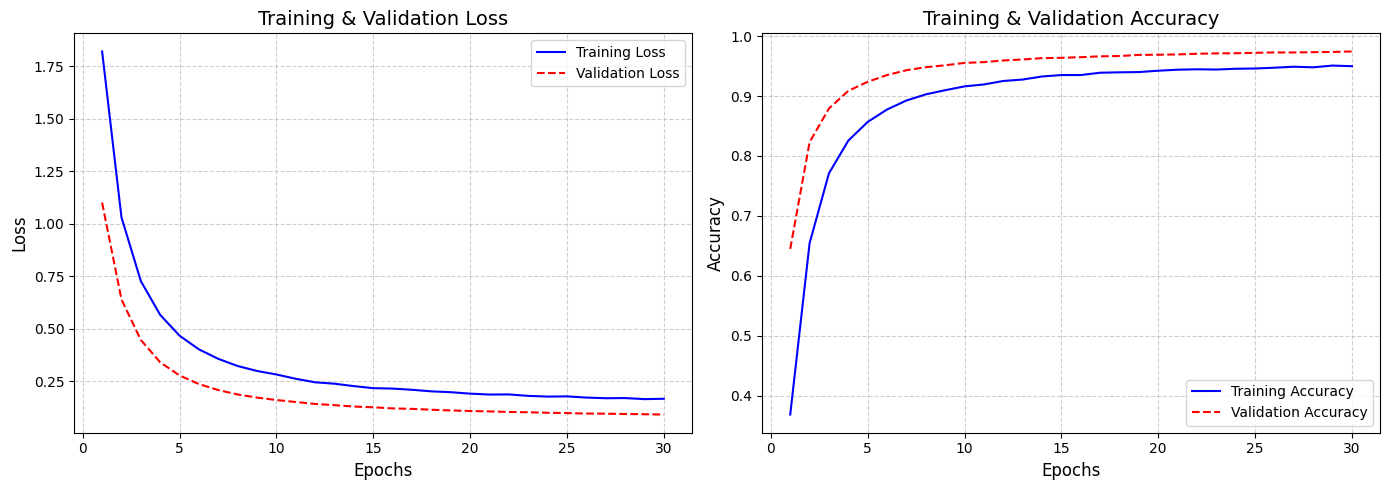

In [ ]:
plot_performance(history)

## Frist model evaluation

Let's see the performance we obtain on the test set.

In [ ]:
score = first_model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {score[0]}')
print(f'Test accuracy: {score[1]}')

Test loss: 0.08769501000642776
Test accuracy: 0.9729999899864197


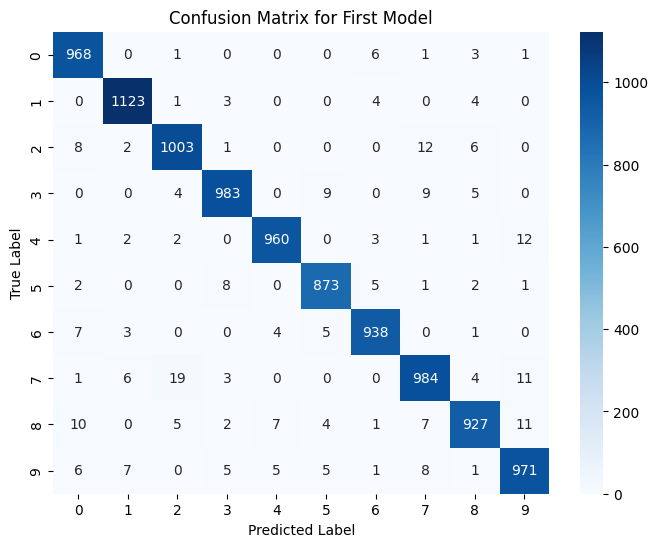

In [ ]:
y_pred = np.argmax(first_model.predict(x_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for First Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Second model


In [ ]:
input_shape = x_test[0].shape
second_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),

        layers.Conv2D(8, kernel_size=(7, 7), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(num_class, activation="softmax")

    ]
)

second_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics = ['accuracy']
)

second_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 8)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 11, 11, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,138 (16.16 KB)

 Trainable params: 4,138 (16.16 KB)

 Non-trainable params: 0 (0.00 B)

## Second model training

In [ ]:
second_history = second_model.fit(x_train, y_train, batch_size=128, epochs=30,
                    validation_split=0.2)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5791 - loss: 1.2603 - val_accuracy: 0.9299 - val_loss: 0.2492
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9052 - loss: 0.3209 - val_accuracy: 0.9553 - val_loss: 0.1572
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9339 - loss: 0.2211 - val_accuracy: 0.9634 - val_loss: 0.1284
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9456 - loss: 0.1835 - val_accuracy: 0.9699 - val_loss: 0.1055
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9501 - loss: 0.1634 - val_accuracy: 0.9739 - val_loss: 0.0949
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1451 - val_accuracy: 0.9764 - val_loss: 0.0864
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9594 - loss: 0.1335 - val_accuracy: 0.9770 - val_loss: 0.0833
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9618 - loss: 0.1279 - val_accuracy: 0.

## Second model evaluation

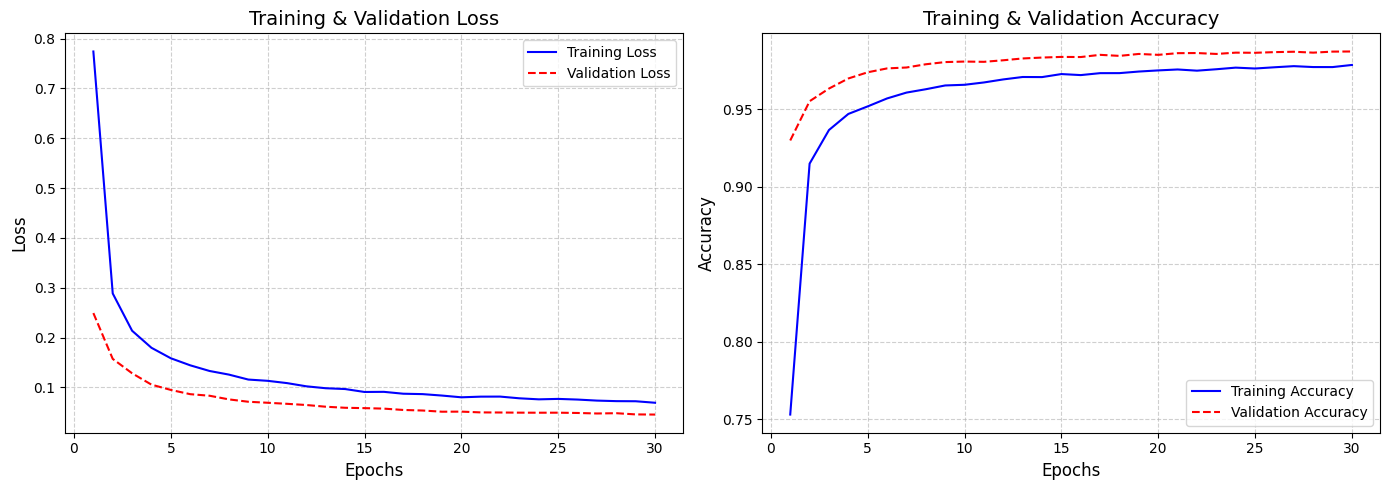

In [ ]:
plot_performance(second_history)

In [ ]:
second_score = second_model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {second_score[0]}')
print(f'Test accuracy: {second_score[1]}')

Test loss: 0.03496534004807472
Test accuracy: 0.9891999959945679


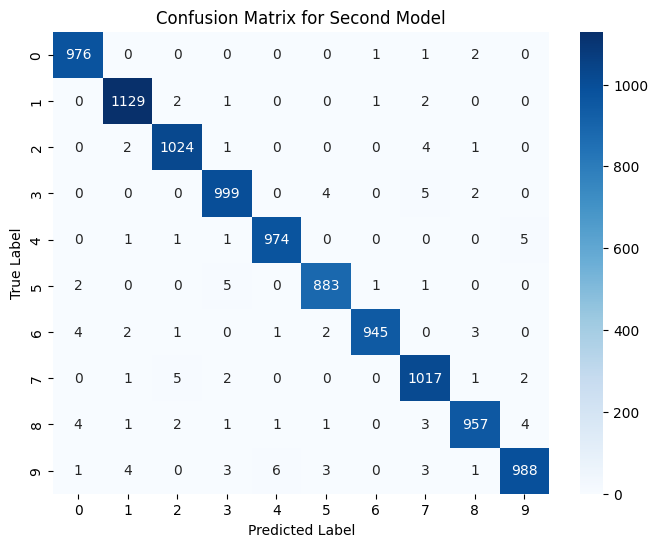

In [ ]:
y_pred = np.argmax(second_model.predict(x_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Second Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Third model

In [ ]:
input_shape = x_test[0].shape
third_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(8, kernel_size=(3, 3), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Conv2D(8, kernel_size=(3, 3), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),

        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(num_class, activation="softmax")

    ]
)

third_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = keras.optimizers.Adam(learning_rate=0.005),
    metrics = ['accuracy']
)

third_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 13, 13, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 5, 5, 8)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 3, 3, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,282 (12.82 KB)

 Trainable params: 3,282 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
third_history = third_model.fit(x_train, y_train, batch_size=128, epochs=30,
                    validation_split=0.2)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7592 - loss: 0.7761 - val_accuracy: 0.9572 - val_loss: 0.1443
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9424 - loss: 0.1921 - val_accuracy: 0.9722 - val_loss: 0.0910
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9551 - loss: 0.1429 - val_accuracy: 0.9801 - val_loss: 0.0723
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9648 - loss: 0.1134 - val_accuracy: 0.9803 - val_loss: 0.0675
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9666 - loss: 0.1041 - val_accuracy: 0.9818 - val_loss: 0.0635
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9713 - loss: 0.0918 - val_accuracy: 0.9841 - val_loss: 0.0566
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9741 - loss: 0.0838 - val_accuracy: 0.9850 - val_loss: 0.0517
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9743 - loss: 0.0828 - val_accuracy: 0.

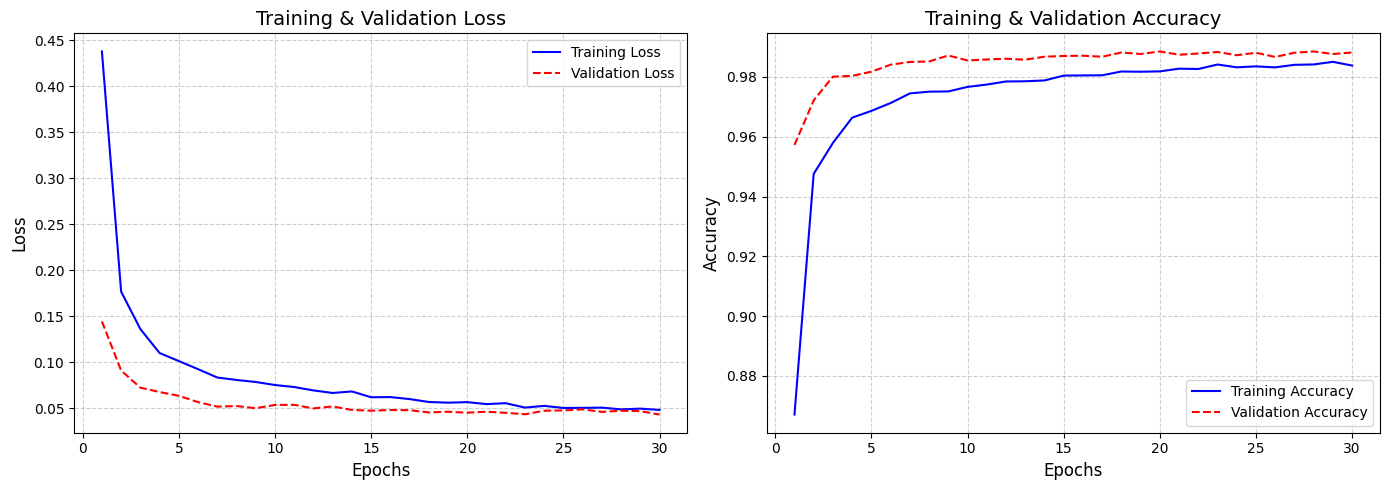

In [ ]:
plot_performance(third_history)

In [ ]:
third_score = third_model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {third_score[0]}')
print(f'Test accuracy: {third_score[1]}')

Test loss: 0.031151074916124344
Test accuracy: 0.9901999831199646


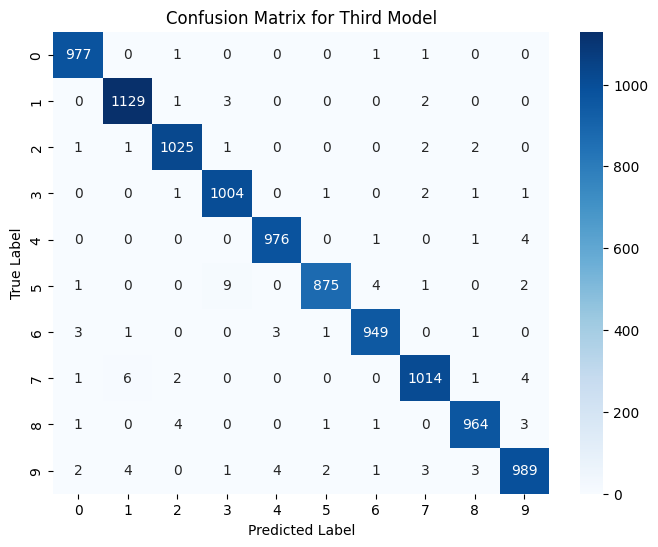

In [ ]:
y_pred = np.argmax(third_model.predict(x_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Third Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC evaluation

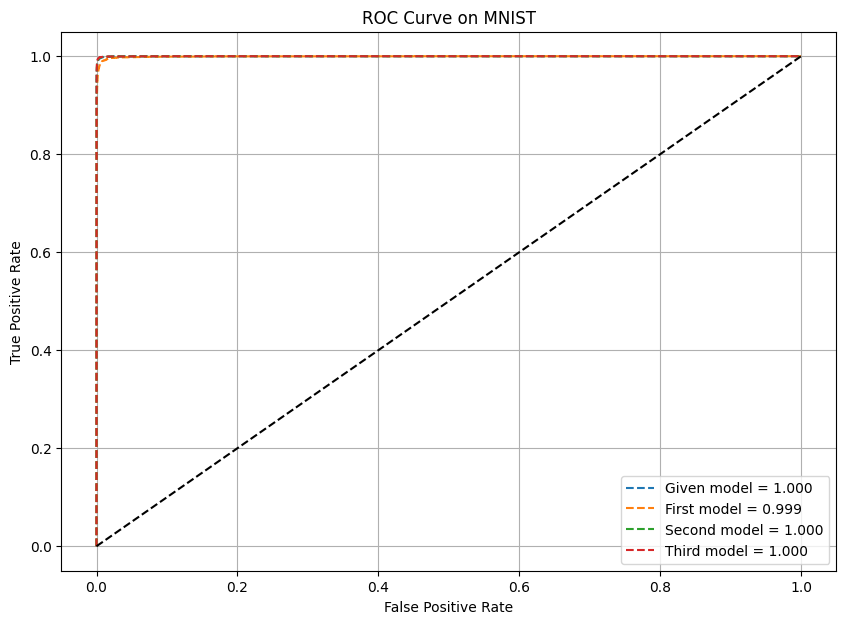

In [ ]:
models = [given_model, first_model, second_model, third_model]
model_names = ["Given model", "First model", "Second model", "Third model"]

plt.figure(figsize=(10, 7))

for model, name in zip(models, model_names):

    # model prediction
    y_score = model.predict(x_test, verbose=0)

    # dictionaries
    fpr = {}
    tpr = {}
    roc_auc = {}

    # ROC with micro-average because the class are not equally distributed
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr_micro, tpr_micro, _ = roc_curve(
        y_test.ravel(),
        y_score.ravel()
    )
    micro_auc = auc(fpr_micro, tpr_micro)

    plt.plot(fpr_micro, tpr_micro,
             linestyle='--',
             label=f"{name} = {micro_auc:.3f}")

# random classifier
plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve on MNIST")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()